# Demo Notebook 1 — Dataset Contents Explorer

**NeuroBench** streams real neurophysiology recordings from the [DANDI Archive](https://dandiarchive.org/) and asks AI models questions whose answers are anchored to **objective, externally-validated ground truth**.

This notebook shows *what is actually inside* the datasets before any questions are written — the raw signals, the metadata, and, critically, **where the ground-truth labels live**. We start with the pilot dataset (**DANDI:000458**) and scaffold sections for the other four.

> Everything is streamed lazily via `remfile` — no dataset is downloaded in full.

## Setup

Add the repo root to `sys.path` so the `data` package is importable, then load the dataset registry.

In [1]:
import pathlib
import sys

# Find the repo root (the directory containing pyproject.toml) walking up from CWD.
_here = pathlib.Path.cwd()
ROOT = next((p for p in [_here, *_here.parents] if (p / "pyproject.toml").exists()), _here)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

from data import datasets
from data.nwb_access import list_assets, load_nwb

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 4)
print("repo root:", ROOT)

repo root: /Users/cechava/Documents/neuro_bench


## The five datasets

Each category draws from one DANDI dataset. Versions are pinned for reproducibility (two are still to be pinned when their categories are built).

In [2]:
import pandas as pd

registry = pd.DataFrame(
    [
        {
            "dandi_id": d.dandi_id,
            "category": d.category,
            "name": d.name,
            "modality": d.modality,
            "version": d.version or "(unpinned)",
        }
        for d in sorted(datasets.DATASETS.values(), key=lambda d: d.category)
    ]
)
registry

,dandi_id,category,name,modality,version
0,000409,1,IBL Brain Wide Map,Neuropixels extracellular ephys,0.260309.1324
1,000035,2,Patch-seq mouse motor cortex (Gouwens et al.),Patch-seq (ephys + transcriptomics),0.211014.0808
2,000458,3,Simultaneous EEG + extracellular ephys + corti...,"Multi-modal (EEG, LFP, spikes)",0.230317.0039
3,000003,4,Hippocampal granule cells and mossy cells (Sen...,Tetrode ephys + LFP,(unpinned)
4,000552,5,Hippocampus embryonic birthdate (Bhaskaran et ...,Tetrode ephys,(unpinned)


---
# Category 3 pilot — DANDI:000458

**Modality:** simultaneous EEG + extracellular ephys + cortical imaging in mouse.

**Ground truth (as verified in the Stage-1 audit):** brain state = **awake vs. isoflurane anesthesia**. The labels live in two interval tables:
- `intervals['epochs']` — `tags` mark `isoflurane_induction` / `isoflurane_anesthesia` windows.
- `intervals['trials']` — `behavioral_epoch` marks `awake` (among other per-trial fields).

These labels are assigned by the experimenter's protocol, independently of the EEG spectrum — so the EEG is a genuine, non-circular predictor of the state.

In [3]:
DS = datasets.get_dataset("000458")
assets = list_assets(DS.dandi_id, DS.version, "*.nwb")
print(f"{DS.name}\nversion {DS.version} — {len(assets)} NWB assets\n")
for a in assets[:5]:
    print(" ", a)
print("  ...")

Simultaneous EEG + extracellular ephys + cortical imaging
version 0.230317.0039 — 24 NWB assets

  sub-521885/sub-521885_ses-20200709_behavior+ecephys.nwb
  sub-521886/sub-521886_ses-20200716_behavior+ecephys.nwb
  sub-521887/sub-521887_ses-20200730_behavior+ecephys.nwb
  sub-543393/sub-543393_ses-20200820_behavior+ecephys.nwb
  sub-543394/sub-543394_ses-20200827_behavior+ecephys.nwb
  ...


### Stream one session and inspect its metadata

In [4]:
ASSET = "sub-521885/sub-521885_ses-20200709_behavior+ecephys.nwb"
handle = load_nwb(DS.dandi_id, DS.version, ASSET)
nwb = handle.nwb

print("identifier        :", nwb.identifier)
print("session desc      :", nwb.session_description)
print("session start     :", nwb.session_start_time)
print("subject id / sex  :", nwb.subject.subject_id, "/", getattr(nwb.subject, "sex", "?"))
print("species           :", getattr(nwb.subject, "species", "?"))
print("acquisition       :", list(nwb.acquisition.keys()))
print("processing        :", list(nwb.processing.keys()))
print("interval tables   :", list(nwb.intervals.keys()))
print("units present     :", nwb.units is not None)

identifier        : 521885-20200709-v001
session desc      : EEG recording during wakefulness and isoflurane anesthesia
session start     : 2020-07-09 14:17:02.725000-07:00
subject id / sex  : 521885 / M
species           : Mus musculus
acquisition       : ['ElectricalSeriesEEG']
processing        : ['behavior']
interval tables   : ['epochs', 'trials']
units present     : False


### The EEG signal

The recording exposes a single `ElectricalSeriesEEG` (30 channels). It uses explicit timestamps rather than a fixed `rate`, so we derive the effective sampling frequency from the first/last timestamps (cheap — we only read two values, not the whole 6M-sample vector).

In [5]:
es = nwb.acquisition["ElectricalSeriesEEG"]
n_samples, n_channels = es.data.shape
t0 = float(es.timestamps[0])
t1 = float(es.timestamps[-1])
fs = (n_samples - 1) / (t1 - t0)
print(f"channels      : {n_channels}")
print(f"samples       : {n_samples:,}")
print(f"time span     : {t0:.1f}s to {t1:.1f}s ({(t1 - t0) / 60:.1f} min)")
print(f"effective fs  : {fs:.1f} Hz")


def time_to_index(t):
    """Map an absolute recording time (s) to a sample index."""
    return int(round((t - t0) * fs))


def eeg_window(t_start, duration, channel=0):
    """Stream a single-channel EEG window [t_start, t_start+duration)."""
    i0, i1 = time_to_index(t_start), time_to_index(t_start + duration)
    return np.asarray(es.data[i0:i1, channel], dtype=float)

channels      : 30
samples       : 6,217,728
time span     : 406.5s to 2893.5s (41.5 min)
effective fs  : 2500.0 Hz


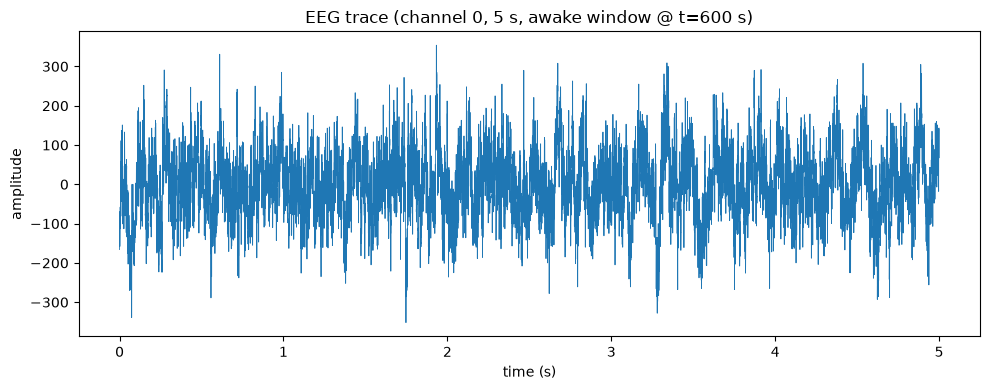

In [6]:
# Plot a 5-second EEG trace from an awake window (before isoflurane induction).
seg = eeg_window(600.0, 5.0, channel=0)
t = np.arange(seg.size) / fs
plt.plot(t, seg, lw=0.6)
plt.title("EEG trace (channel 0, 5 s, awake window @ t=600 s)")
plt.xlabel("time (s)")
plt.ylabel("amplitude")
plt.tight_layout()
plt.show()

### Where the ground truth lives: the label tables

`epochs` gives the anesthesia windows; `trials` gives per-event labels including `behavioral_epoch`.

In [7]:
epochs = nwb.intervals["epochs"].to_dataframe()
epochs["tags"] = epochs["tags"].apply(lambda x: list(x))
print("EPOCHS (anesthesia state windows):")
epochs

EPOCHS (anesthesia state windows):


,start_time,stop_time,tags
id,,,
0,1308.80961,1706.35898,[isoflurane_induction]
1,1706.35898,2425.15797,[isoflurane_anesthesia]


In [8]:
trials = nwb.intervals["trials"].to_dataframe()
print(f"TRIALS: {len(trials)} rows, columns = {list(trials.columns)}\n")
print("behavioral_epoch value counts:")
print(trials["behavioral_epoch"].value_counts())
trials.head()

TRIALS: 360 rows, columns = ['start_time', 'stop_time', 'stimulus_type', 'stimulus_description', 'estim_current', 'estim_target_region', 'estim_target_depth', 'behavioral_epoch', 'is_running', 'is_valid']

behavioral_epoch value counts:
behavioral_epoch
awake         180
isoflurane    180
Name: count, dtype: int64


,start_time,stop_time,stimulus_type,stimulus_description,estim_current,estim_target_region,estim_target_depth,behavioral_epoch,is_running,is_valid
id,,,,,,,,,,
0,590.01039,590.01100,electrical,biphasic,50,MOs,superficial,awake,False,True
1,593.77976,593.78036,electrical,biphasic,20,MOs,superficial,awake,False,True
2,597.48012,597.48073,electrical,biphasic,20,MOs,superficial,awake,False,True
3,601.73597,601.73658,electrical,biphasic,50,MOs,superficial,awake,False,True
4,605.25276,605.25336,electrical,biphasic,20,MOs,superficial,awake,False,True


### Previewing the ground-truth signal: awake vs. anesthetized spectra

We compute the power spectral density (Welch) of one EEG channel in an **awake** window vs. an **isoflurane-anesthesia** window. Anesthesia characteristically increases low-frequency (delta) power and suppresses higher frequencies — the signature a model must detect. This is the analysis a Category-3 question will require.

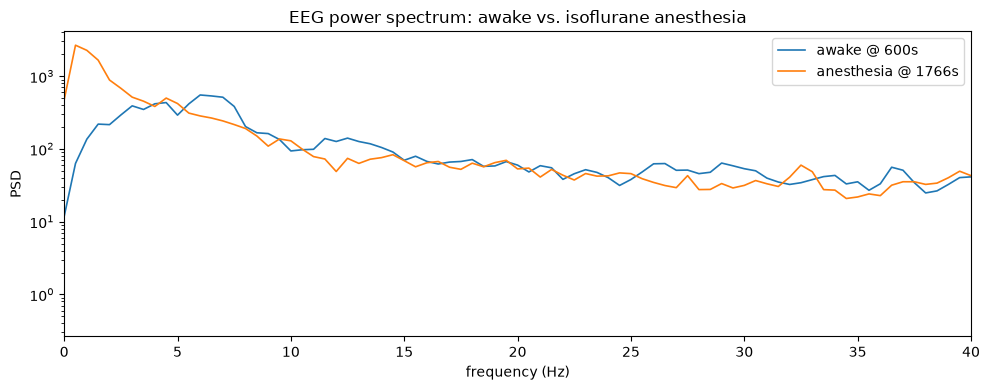

      awake: delta/total power ratio = 0.156
 anesthesia: delta/total power ratio = 0.545


In [9]:
# Pick one awake window (pre-induction) and one anesthesia window from the epochs table.
anes = epochs[epochs["tags"].apply(lambda t: "isoflurane_anesthesia" in t)].iloc[0]
awake_start = 600.0  # well before induction
anes_start = float(anes["start_time"]) + 60.0  # 1 min into stable anesthesia
WIN = 30.0  # seconds

awake_seg = eeg_window(awake_start, WIN, channel=0)
anes_seg = eeg_window(anes_start, WIN, channel=0)

f_a, p_a = signal.welch(awake_seg, fs=fs, nperseg=int(fs * 2))
f_n, p_n = signal.welch(anes_seg, fs=fs, nperseg=int(fs * 2))

plt.semilogy(f_a, p_a, label=f"awake @ {awake_start:.0f}s", lw=1.2)
plt.semilogy(f_n, p_n, label=f"anesthesia @ {anes_start:.0f}s", lw=1.2)
plt.xlim(0, 40)
plt.xlabel("frequency (Hz)")
plt.ylabel("PSD")
plt.title("EEG power spectrum: awake vs. isoflurane anesthesia")
plt.legend()
plt.tight_layout()
plt.show()


def band_power(f, p, lo, hi):
    m = (f >= lo) & (f < hi)
    return float(np.trapezoid(p[m], f[m]))


for label, (f, p) in {"awake": (f_a, p_a), "anesthesia": (f_n, p_n)}.items():
    delta = band_power(f, p, 0.5, 4)
    total = band_power(f, p, 0.5, 40)
    print(f"{label:>11}: delta/total power ratio = {delta / total:.3f}")

### Ground-truth summary for the pilot

| What | Where in the NWB file | Type |
|---|---|---|
| Brain-state windows (awake / induction / anesthesia) | `intervals['epochs'].tags` | categorical |
| Per-trial behavioral state | `intervals['trials'].behavioral_epoch` | categorical |
| Raw signal to analyze | `acquisition['ElectricalSeriesEEG']` | 30-ch time series |

The label is set by the experimental protocol; the EEG spectrum is an independent predictor of it — exactly the non-circular structure NeuroBench requires.

In [10]:
# Release the streamed file handles.
handle.close()
print("closed")

closed


---
# Other datasets (scaffold)

These sections will be filled in during Stage 8 replication, following the same pattern: stream one asset, inspect metadata + signals, and locate the ground-truth labels.

## Category 1 — DANDI:000409 (IBL Brain Wide Map)
- **Signal:** Neuropixels extracellular spikes + mean waveforms.
- **Ground truth:** brain region in `electrodes.location` (histology + Allen CCF).

## Category 2 — DANDI:000035 (Patch-seq, Gouwens et al.)
- **Signal:** patch-clamp current-injection sweeps (one neuron per file).
- **Ground truth:** transcriptomic cell type (t-type) in file metadata.

## Category 4 — DANDI:000003 (Senzai & Buzsaki)
- **Signal:** tetrode spikes + LFP in dentate gyrus.
- **Ground truth:** granule cell vs. mossy cell labels (juxtacellular-validated).

## Category 5 — DANDI:000552 (Bhaskaran et al.)
- **Signal:** CA1 population spike trains.
- **Ground truth:** embryonic birthdate (E14–E17) per neuron (BrdU birthdating).

> **TODO:** pin published versions for 000003 and 000552 in `data/datasets.py` before building their questions.